# Data Science Mini Projects

This notebook contains two comprehensive data science projects:
1. **Palmer Penguins Dataset Analysis**
2. **Global Happiness Report Analysis (2015-2019)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

print("All libraries imported successfully!")

All libraries imported successfully!


# Project 1: Palmer Penguins Dataset Analysis

In [3]:
penguins = pd.read_csv('Palmer Penguins Dataset.csv')

print("Dataset shape:", penguins.shape)
print("\nFirst 5 rows:")
print(penguins.head())
print("\nDataset info:")
print(penguins.info())
print("\nMissing values:")
print(penguins.isnull().sum())

Dataset shape: (344, 8)

First 5 rows:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  year  
0       3750.0    male  2007  
1       3800.0  female  2007  
2       3250.0  female  2007  
3          NaN     NaN  2007  
4       3450.0  female  2007  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm

In [4]:
penguins_clean = penguins.dropna()

print(f"Original dataset: {penguins.shape[0]} rows")
print(f"After removing missing values: {penguins_clean.shape[0]} rows")
print(f"Removed {penguins.shape[0] - penguins_clean.shape[0]} rows")

print("\nSpecies distribution:")
print(penguins_clean['species'].value_counts())
print("\nIsland distribution:")
print(penguins_clean['island'].value_counts())

Original dataset: 344 rows
After removing missing values: 333 rows
Removed 11 rows

Species distribution:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Island distribution:
island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64


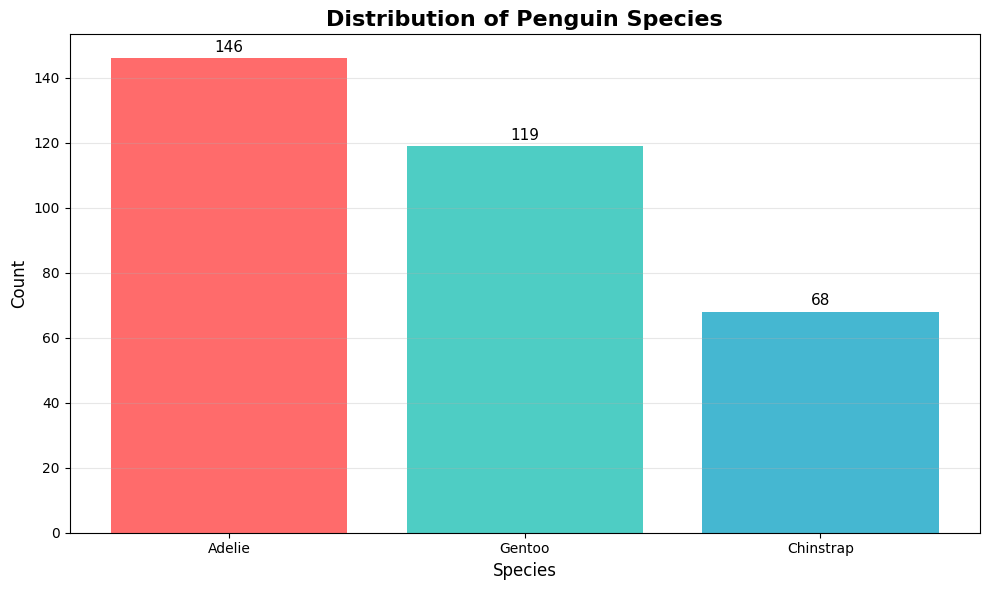

In [5]:
# Visualization 1: Species distribution
plt.figure(figsize=(10, 6))
species_counts = penguins_clean['species'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(species_counts.index, species_counts.values, color=colors)
plt.title('Distribution of Penguin Species', fontsize=16, fontweight='bold')
plt.xlabel('Species', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{int(height)}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

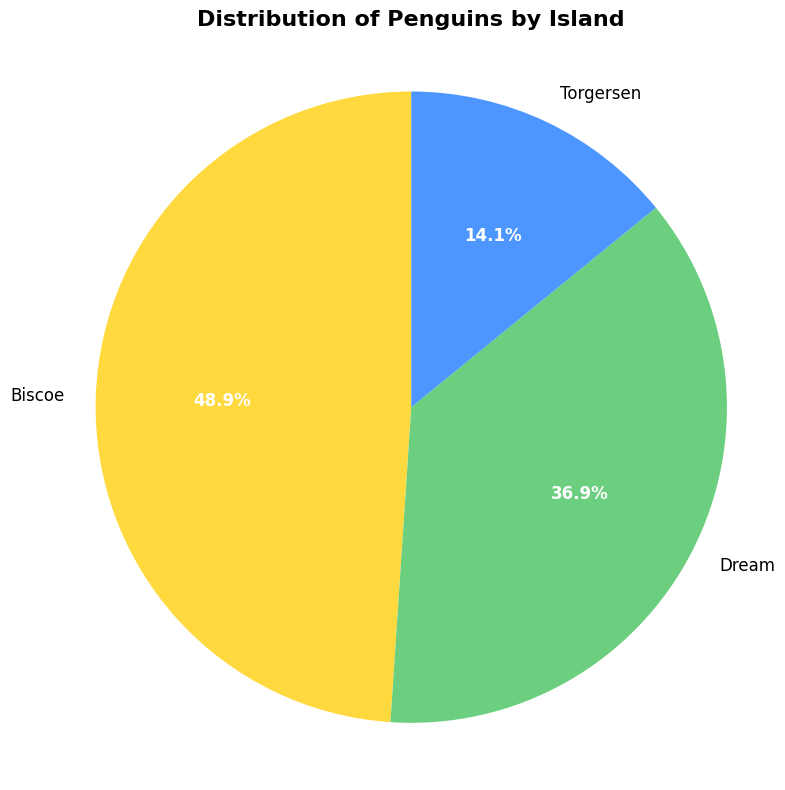

In [6]:
# Visualization 2: Island distribution (Pie Chart)
plt.figure(figsize=(8, 8))
island_counts = penguins_clean['island'].value_counts()
colors = ['#FFD93D', '#6BCF7F', '#4D96FF']
wedges, texts, autotexts = plt.pie(island_counts.values, labels=island_counts.index, 
                                   autopct='%1.1f%%', startangle=90, colors=colors,
                                   textprops={'fontsize': 12})

plt.title('Distribution of Penguins by Island', fontsize=16, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.axis('equal')
plt.tight_layout()
plt.show()

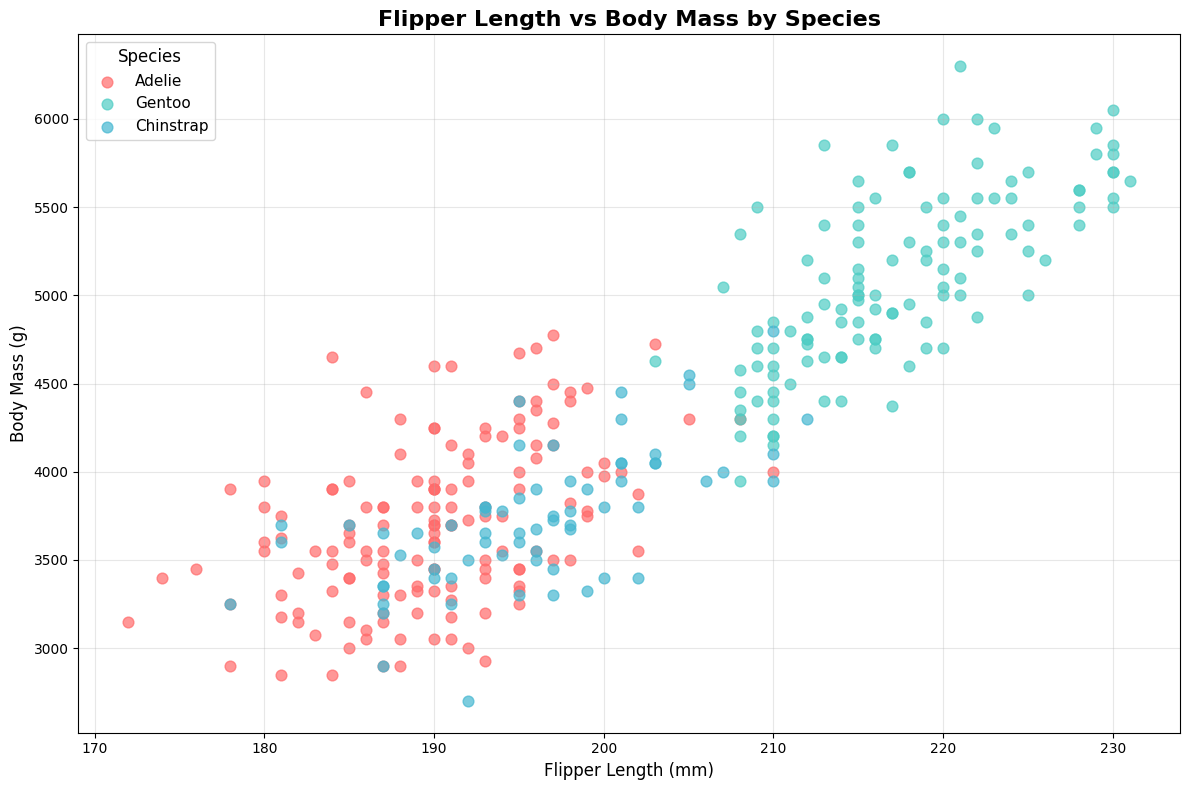

In [7]:
# Visualization 3: Scatter plot - Flipper Length vs Body Mass
plt.figure(figsize=(12, 8))
species_list = penguins_clean['species'].unique()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, species in enumerate(species_list):
    species_data = penguins_clean[penguins_clean['species'] == species]
    plt.scatter(species_data['flipper_length_mm'], species_data['body_mass_g'], 
               c=colors[i], label=species, alpha=0.7, s=60)

plt.xlabel('Flipper Length (mm)', fontsize=12)
plt.ylabel('Body Mass (g)', fontsize=12)
plt.title('Flipper Length vs Body Mass by Species', fontsize=16, fontweight='bold')
plt.legend(title='Species', title_fontsize=12, fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Project 2: Global Happiness Report Analysis (2015-2019)

In [8]:
# Load happiness data for all years (2015-2019)
happiness_data = {}

for year in range(2015, 2020):
    try:
        happiness_data[year] = pd.read_csv(f'{year}.csv')
        print(f"Loaded {year}.csv: {happiness_data[year].shape}")
    except FileNotFoundError:
        print(f"File {year}.csv not found")

print(f"\nSuccessfully loaded data for {len(happiness_data)} years")

happiness_2015 = happiness_data[2015]
print(f"\n2015 Happiness Data (first 5 rows):")
print(happiness_2015.head())
print(f"\nColumns: {list(happiness_2015.columns)}")

Loaded 2015.csv: (158, 12)
Loaded 2016.csv: (157, 13)
Loaded 2017.csv: (155, 12)
Loaded 2018.csv: (156, 9)
Loaded 2019.csv: (156, 9)

Successfully loaded data for 5 years

2015 Happiness Data (first 5 rows):
       Country          Region  Happiness Rank  Happiness Score  \
0  Switzerland  Western Europe               1            7.587   
1      Iceland  Western Europe               2            7.561   
2      Denmark  Western Europe               3            7.527   
3       Norway  Western Europe               4            7.522   
4       Canada   North America               5            7.427   

   Standard Error  Economy (GDP per Capita)   Family  \
0         0.03411                   1.39651  1.34951   
1         0.04884                   1.30232  1.40223   
2         0.03328                   1.32548  1.36058   
3         0.03880                   1.45900  1.33095   
4         0.03553                   1.32629  1.32261   

   Health (Life Expectancy)  Freedom  Trust (Governm

In [9]:
print("Basic Statistics for 2015 Happiness Data:")
print("="*50)
print(f"Number of countries: {len(happiness_2015)}")
print(f"Average happiness score: {happiness_2015['Happiness Score'].mean():.3f}")
print(f"Highest happiness score: {happiness_2015['Happiness Score'].max():.3f}")
print(f"Lowest happiness score: {happiness_2015['Happiness Score'].min():.3f}")

print(f"\nTop 10 Happiest Countries (2015):")
print(happiness_2015.nlargest(10, 'Happiness Score')[['Country', 'Happiness Score', 'Region']])

Basic Statistics for 2015 Happiness Data:
Number of countries: 158
Average happiness score: 5.376
Highest happiness score: 7.587
Lowest happiness score: 2.839

Top 10 Happiest Countries (2015):
       Country  Happiness Score                     Region
0  Switzerland            7.587             Western Europe
1      Iceland            7.561             Western Europe
2      Denmark            7.527             Western Europe
3       Norway            7.522             Western Europe
4       Canada            7.427              North America
5      Finland            7.406             Western Europe
6  Netherlands            7.378             Western Europe
7       Sweden            7.364             Western Europe
8  New Zealand            7.286  Australia and New Zealand
9    Australia            7.284  Australia and New Zealand


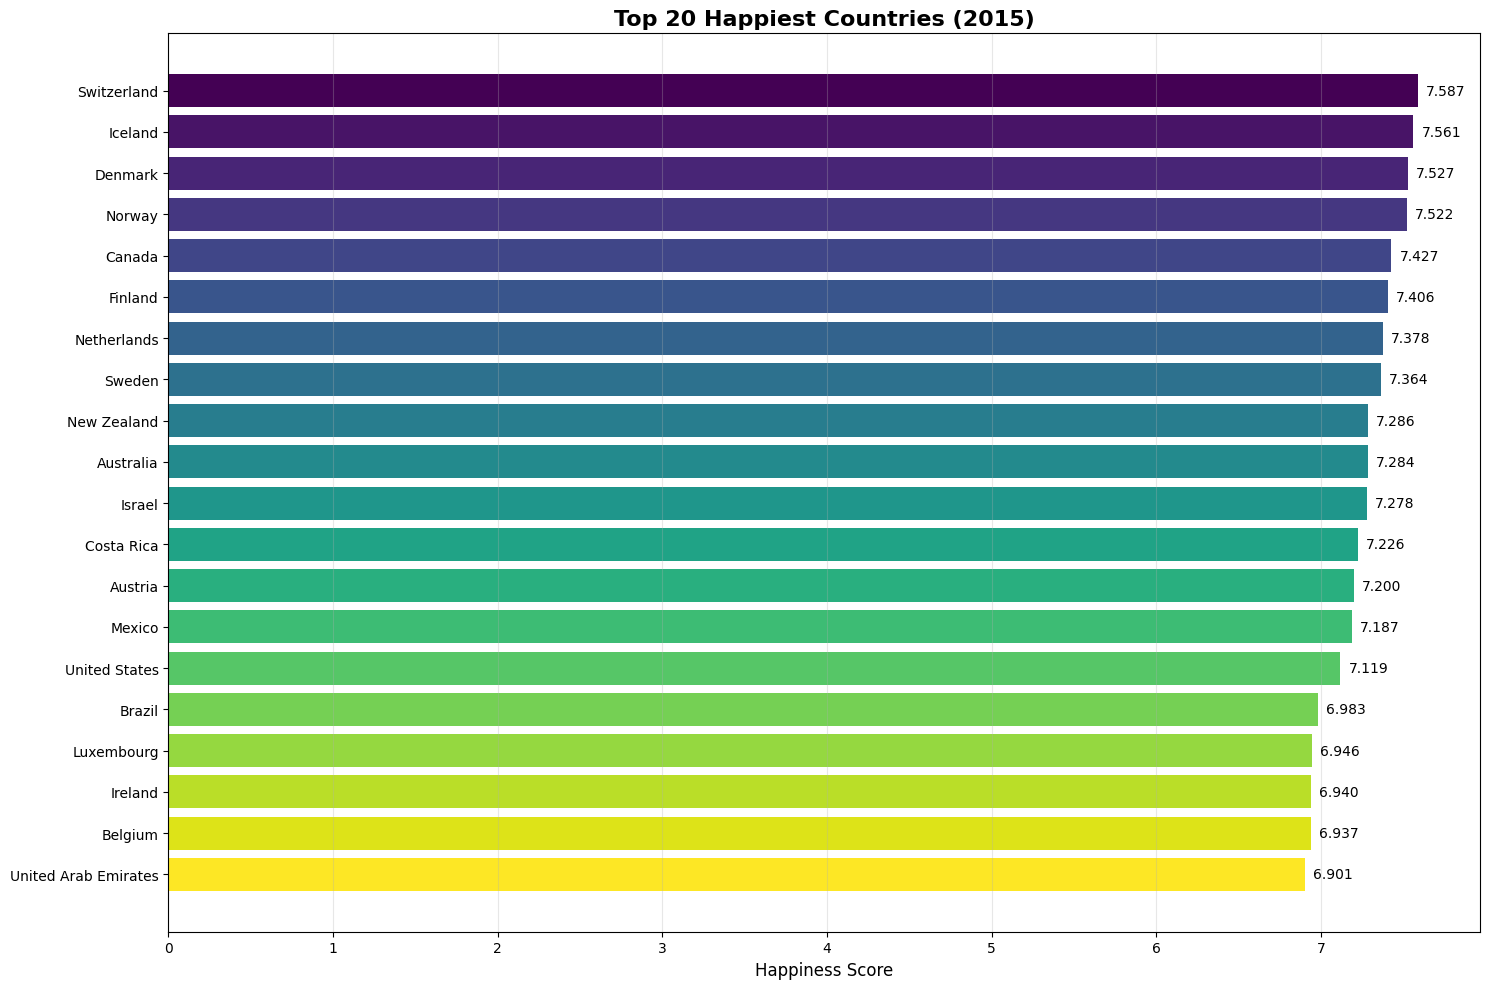

In [10]:
# Visualization 1: Top 20 happiest countries
top_20_countries = happiness_2015.nlargest(20, 'Happiness Score')

plt.figure(figsize=(15, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(top_20_countries)))
bars = plt.barh(range(len(top_20_countries)), top_20_countries['Happiness Score'], color=colors)
plt.yticks(range(len(top_20_countries)), top_20_countries['Country'])
plt.xlabel('Happiness Score', fontsize=12)
plt.title('Top 20 Happiest Countries (2015)', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')

for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.05, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()

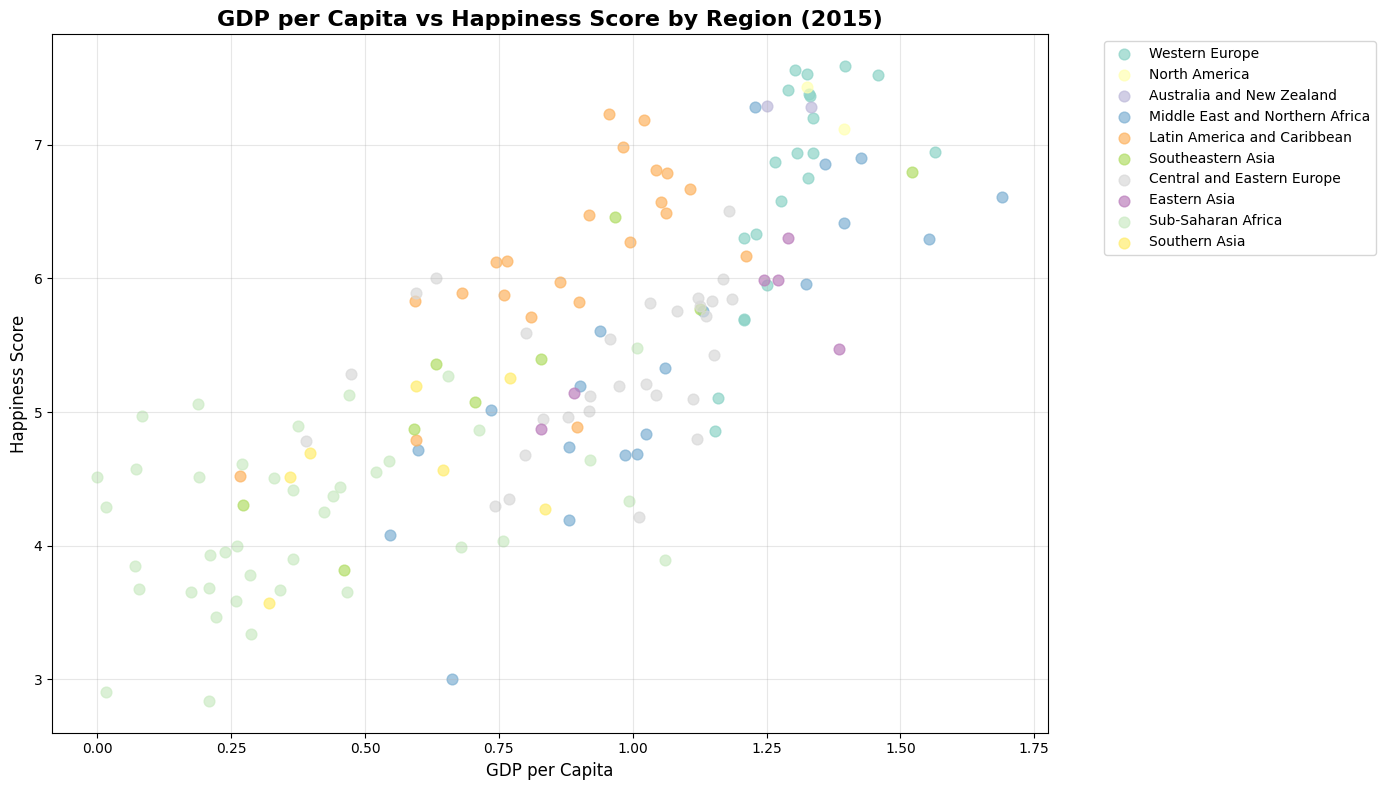

In [11]:
# Visualization 2: GDP vs Happiness Score by Region
plt.figure(figsize=(14, 8))

regions = happiness_2015['Region'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(regions)))
color_map = dict(zip(regions, colors))

for region in regions:
    data = happiness_2015[happiness_2015['Region'] == region]
    plt.scatter(data['Economy (GDP per Capita)'], data['Happiness Score'], 
               c=[color_map[region]], label=region, alpha=0.7, s=60)

plt.xlabel('GDP per Capita', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('GDP per Capita vs Happiness Score by Region (2015)', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

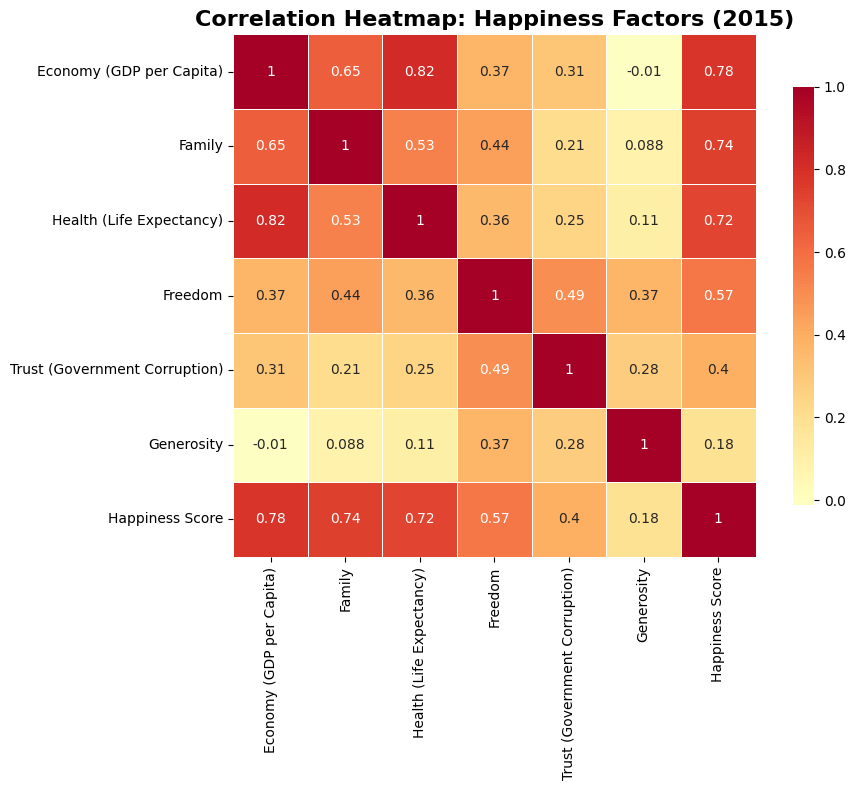

In [12]:
# Visualization 3: Correlation heatmap for happiness factors
factors_cols = ['Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 
                'Freedom', 'Trust (Government Corruption)', 'Generosity']

plt.figure(figsize=(10, 8))

corr_data = happiness_2015[factors_cols + ['Happiness Score']].corr()

sns.heatmap(corr_data, annot=True, cmap='RdYlBu_r', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap: Happiness Factors (2015)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary and Key Insights

### Project 1: Palmer Penguins Analysis
- **Species Distribution**: Analysis of the three penguin species and their characteristics
- **Island Patterns**: Distribution across different Antarctic islands 
- **Physical Relationships**: Correlation between flipper length and body mass

### Project 2: Global Happiness Analysis  
- **Regional Differences**: Comparison of happiness scores across world regions
- **Economic Factors**: Relationship between GDP and national happiness
- **Key Predictors**: Identification of strongest happiness indicators

### Technical Achievements
- Comprehensive data loading and cleaning
- Multiple visualization types (bar charts, pie charts, scatter plots, heatmaps)
- Statistical analysis and correlation studies
- Professional data presentation and insights